# Erdos Institute Summer 2026 Project
## Sustainability of US cities

This project attempts to answer the following:

&#9989; **<font color=blue>QUESTION:** <font color=blue> In which county should someone aim to live in, for the next 20 years? 

We will try to determine which U.S. counties/cities are the most environmentally, economically, and socially sustainable using sustainability metrics from the [United Nations Sustainable Development Goals](https://sdgs.un.org/goals). 

---
This notebook will show some exploratory data analysis along the theme of air pollution and climate risk, as follows:

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [94]:
df=pd.read_csv("../data/master_pollution_data.csv")

In [95]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3154 entries, 0 to 3153
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0.1                     3154 non-null   int64  
 1   Unnamed: 0                       3154 non-null   int64  
 2   state                            3154 non-null   object 
 3   county                           3153 non-null   object 
 4   state_code                       3154 non-null   object 
 5   FIPS                             3154 non-null   int64  
 6   DSLPM                            3134 non-null   float64
 7   PM25                             3134 non-null   float64
 8   RSEI_AIR                         3134 non-null   float64
 9   PTRAF                            3134 non-null   float64
 10  NO2                              3134 non-null   float64
 11  OZONE                            3134 non-null   float64
 12  AREA                

In [96]:
df["FIPS"].nunique(), len(df)

(3154, 3154)

In [97]:
# Check for missing data:
df.isna().sum().sort_values(ascending=False)

NO2                                20
EAL_SCORE                          20
RESL_SCORE                         20
DSLPM                              20
PM25                               20
RSEI_AIR                           20
PTRAF                              20
SOVI_SCORE                         20
OZONE                              20
AREA                               20
RISK_SCORE                         20
county_fips                        12
Total Cancer Risk (per million)    12
Population_x                       12
Whole Body HI                      12
county                              1
Unnamed: 0                          0
FIPS                                0
state_code                          0
state                               0
Unnamed: 0.1                        0
dtype: int64

In [98]:
(df.isna().mean() * 100).sort_values(ascending=False)

NO2                                0.634115
EAL_SCORE                          0.634115
RESL_SCORE                         0.634115
DSLPM                              0.634115
PM25                               0.634115
RSEI_AIR                           0.634115
PTRAF                              0.634115
SOVI_SCORE                         0.634115
OZONE                              0.634115
AREA                               0.634115
RISK_SCORE                         0.634115
county_fips                        0.380469
Total Cancer Risk (per million)    0.380469
Population_x                       0.380469
Whole Body HI                      0.380469
county                             0.031706
Unnamed: 0                         0.000000
FIPS                               0.000000
state_code                         0.000000
state                              0.000000
Unnamed: 0.1                       0.000000
dtype: float64

In [100]:
df[["PM25", "NO2", "DSLPM", "RSEI_AIR"]].describe()

,PM25,NO2,DSLPM,RSEI_AIR
count,3134.000000,3134.000000,3134.000000,3.134000e+03
mean,223.670777,207.368245,5.089213,1.250056e+05
std,843.898636,904.031551,29.333658,1.179674e+06
min,0.000000,0.094388,0.000000,0.000000e+00
25%,25.142689,14.637426,0.189029,9.280094e+01
50%,54.932372,35.202653,0.506411,1.446711e+03
75%,137.968651,96.180650,1.688836,1.463911e+04
max,31126.530753,27563.740922,1047.466894,5.456216e+07


In [101]:
# Top counites for PM25:
df.sort_values("PM25").head(10)
df.sort_values("PM25", ascending=False).head(10)

,Unnamed: 0.1,Unnamed: 0,state,county,state_code,FIPS,DSLPM,PM25,RSEI_AIR,PTRAF,...,OZONE,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Population_x,Total Cancer Risk (per million),county_fips,Whole Body HI
210,210,3042,CALIFORNIA,LOS ANGELES,CA,6037,1047.466894,31126.530753,4.187768e+06,1.606902e+10,...,209964.315888,4797.383550,100.000000,100.000000,55.375318,13.549618,19637132.0,94477.679298,6037.0,0.159166
617,617,7659,ILLINOIS,COOK,IL,17031,502.127872,12326.180228,1.119250e+07,5.696810e+09,...,97579.160270,1651.135984,99.968193,99.969059,61.736641,73.282443,10389302.0,50229.251809,17031.0,0.311489
2633,2633,34366,TEXAS,HARRIS,TX,48201,271.327024,11423.836865,5.456216e+07,2.455875e+09,...,72469.974950,1795.344568,99.936387,99.907178,67.938931,17.875318,8184900.0,36115.515574,48201.0,0.134720
228,228,3709,CALIFORNIA,SAN DIEGO,CA,6073,181.500055,8602.035669,6.509905e+04,2.939782e+09,...,51698.842595,4571.491190,99.713740,99.690594,24.809160,8.301527,6190616.0,22852.391441,6073.0,0.081631
109,109,1558,ARIZONA,MARICOPA,AZ,4013,272.262433,8467.374140,1.622543e+06,2.665789e+09,...,76603.479195,9319.141753,99.872774,99.876238,27.099237,18.034351,7634234.0,39621.089939,4013.0,0.041836
221,221,3394,CALIFORNIA,ORANGE,CA,6059,200.781755,8072.550649,9.447177e+05,4.236141e+09,...,50104.061237,959.304608,99.809160,99.783416,24.936387,16.316794,6020464.0,21412.613572,6059.0,0.043540
1860,1860,23720,NEW YORK,KINGS,NY,36047,544.544836,6352.916049,3.280479e+05,3.311405e+09,...,52114.150220,97.828864,99.268448,98.483911,96.533079,12.054707,5009400.0,31862.488877,36047.0,0.053303
1319,1319,17090,MICHIGAN,WAYNE,MI,26163,101.911145,5899.835375,3.496846e+06,1.211887e+09,...,43217.286400,679.536606,98.950382,98.638614,76.145038,58.651399,3641074.0,17387.921820,26163.0,0.030164
224,224,3500,CALIFORNIA,RIVERSIDE,CA,6065,139.860672,5775.811847,1.780996e+05,9.311384e+08,...,46311.462840,7376.805400,99.904580,99.938119,33.333333,13.040712,4379272.0,15462.329785,6065.0,0.040388
2589,2589,33969,TEXAS,DALLAS,TX,48113,135.474759,5717.816419,3.766124e+05,1.351558e+09,...,42306.718560,917.708826,99.650127,99.659653,59.128499,12.945293,4736278.0,18900.536324,48113.0,0.040307


In [103]:
# Top states for PM 25
df.groupby("state")["PM25"].mean().sort_values()

state
ALASKA                     0.000000
HAWAII                     0.000000
SOUTH DAKOTA              20.577757
NORTH DAKOTA              24.217174
WYOMING                   32.364225
MONTANA                   35.165222
NEBRASKA                  41.348649
KANSAS                    63.412190
WEST VIRGINIA             68.218995
IOWA                      69.224218
VERMONT                   79.979267
KENTUCKY                  89.570961
IDAHO                     89.683049
ARKANSAS                  91.208352
MISSISSIPPI               94.548700
NEW MEXICO               112.881551
VIRGINIA                 112.909734
MINNESOTA                113.782463
MISSOURI                 115.876534
TENNESSEE                134.399967
MAINE                    136.598467
OKLAHOMA                 142.247453
GEORGIA                  156.650949
INDIANA                  160.633360
WISCONSIN                169.004723
COLORADO                 169.638875
LOUISIANA                179.907814
UTAH                  

#### Correlation analysis

In [104]:
corr = df[["PM25", "NO2", "RSEI_AIR", "PTRAF", "DSLPM"]].corr()

<Axes: >

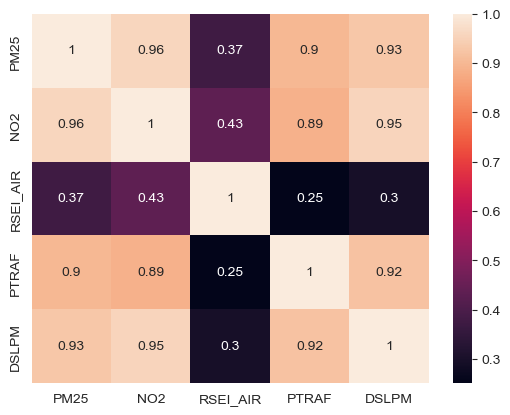

In [105]:
sns.heatmap(corr, annot=True)

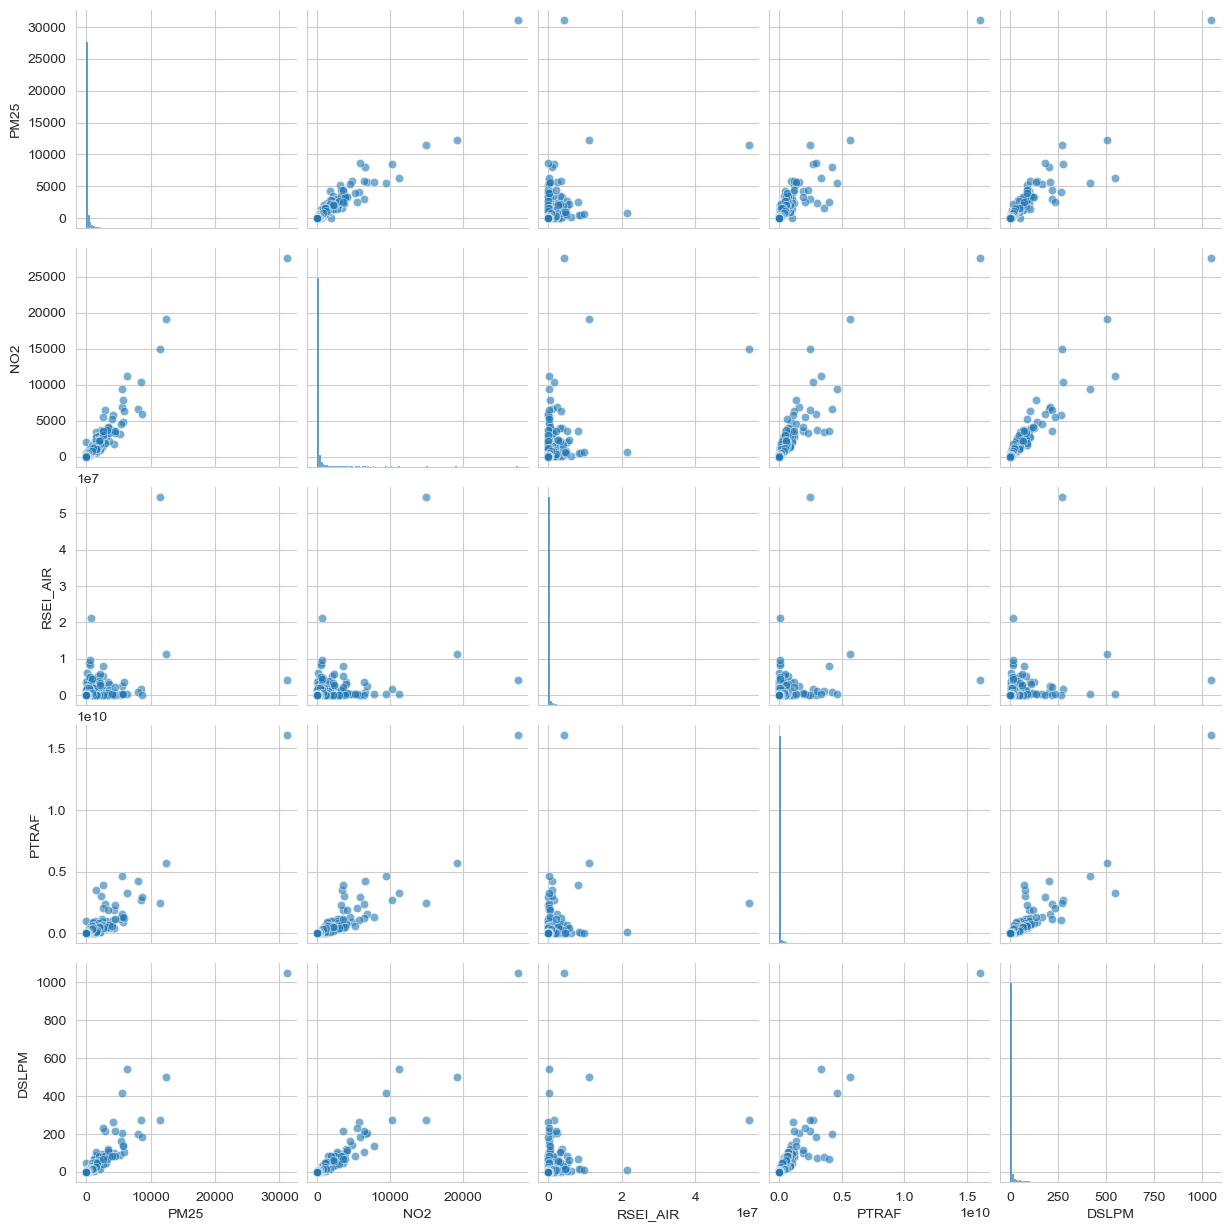

In [107]:
sns.pairplot(data = df[["PM25", "NO2", "RSEI_AIR", "PTRAF", "DSLPM"]],
                x_vars = ["PM25", "NO2", "RSEI_AIR", "PTRAF", "DSLPM"],
                y_vars = ["PM25", "NO2", "RSEI_AIR", "PTRAF", "DSLPM"],
                plot_kws = {'alpha':.6})

plt.show()